In [1]:
#loading filtered rna and atac data
import anndata
from anndata import AnnData
import pandas as pd

pb_atac_ct = anndata.read_h5ad("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Pseudobulks/ATAC/celltypes/agg_atac_ct.h5ad")
pb_rna_ct = anndata.read_h5ad("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Pseudobulks/RNA/celltypes/agg_rna_ct.h5ad")    
gene_peaks_10kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_assignments_10kb.csv")
gene_peaks_20kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_assignments_20kb.csv")
gene_peaks_50kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_assignments_50kb.csv")
gene_peaks_100kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_assignments_100kb.csv")

In [2]:
#Reindex the dataframes to ensure they are in the same order
pb_atac_ct = pb_atac_ct[pb_rna_ct.obs_names, :]
pb_rna_ct = pb_rna_ct[pb_atac_ct.obs_names, :]
print(pb_atac_ct.obs_names.equals(pb_rna_ct.obs_names))  # Should return True

pb_rna_ct.shape

True


(39, 32057)

In [3]:
#Substract the genes that are present in the window dataframe from the pb_rna_ct dataframe, to only keep the genes that have peaks assigned to them
genes_with_peaks_10kb = gene_peaks_10kb["gene_id"].tolist()
pb_rna_ct = pb_rna_ct[:, genes_with_peaks_10kb] 

pb_rna_ct.shape

(39, 19380)

In [4]:
#log transformation (for norm. distribution) & scaling 10000000+1
#log scaling both datasets by multiplying by 10 million and adding 1 to avoid log(0) issues, then taking log10
import numpy as np 
pb_atac_ct.X = np.log10(pb_atac_ct.X * 10000000 + 1)
pb_rna_ct.X = np.log10(pb_rna_ct.X * 10000000 + 1)
print(pb_atac_ct.X)
print(pb_rna_ct.X)

[[0.60292805 0.86432158 1.28326547 ... 0.93044    4.38594663 4.33635703]
 [0.44606136 0.87933146 1.16867014 ... 1.03187497 4.43205636 4.38114173]
 [0.5492541  1.02626586 1.3024465  ... 1.02626586 4.4074836  4.34718958]
 ...
 [0.57053454 1.03309152 1.22467762 ... 0.72850677 4.39864102 4.34898879]
 [0.68053221 1.0142925  1.37035234 ... 0.93370691 4.39607381 4.34516578]
 [0.65971479 1.02178241 1.47045531 ... 0.84176407 4.38308116 4.33193089]]
[[4.12849288 2.62635661 1.31715562 ... 1.65508602 2.36861978 3.59125773]
 [4.16925185 2.59678341 1.23663806 ... 1.70474452 2.19012329 3.62428527]
 [4.16560843 2.60862179 0.98009093 ... 1.72847082 2.04748715 3.61521791]
 ...
 [4.1410468  2.57124568 1.41999061 ... 1.74948843 2.2011887  3.59087206]
 [4.14637779 2.58379715 1.27389386 ... 1.86683249 2.25740086 3.59958275]
 [4.17033421 2.62762064 1.6874581  ... 1.65607999 2.05918542 3.675845  ]]


/tmp/ipykernel_4121716/3230731746.py:4: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  pb_atac_ct.X = np.log10(pb_atac_ct.X * 10000000 + 1)
/tmp/ipykernel_4121716/3230731746.py:5: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  pb_rna_ct.X = np.log10(pb_rna_ct.X * 10000000 + 1)


# peak-wise linear regression per gene


In [5]:
import numpy as np
import pandas as pd
from scipy.stats import linregress
from statsmodels.stats.multitest import multipletests

#1. Run linear regression per peak–gene pair per window
window_assignments_raw = {
    "10kb":  gene_peaks_10kb,
    "20kb":  gene_peaks_20kb,
    "50kb":  gene_peaks_50kb,
    "100kb": gene_peaks_100kb,
}

atac_obj = pb_atac_ct
rna_obj  = pb_rna_ct

# one results dict per window — mirrors your correlation structure
gene_peak_10kb_lm_results  = {}
gene_peak_20kb_lm_results  = {}
gene_peak_50kb_lm_results  = {}
gene_peak_100kb_lm_results = {}

lm_result_stores = {
    "10kb":  gene_peak_10kb_lm_results,
    "20kb":  gene_peak_20kb_lm_results,
    "50kb":  gene_peak_50kb_lm_results,
    "100kb": gene_peak_100kb_lm_results,
}

for window_label, gene_peaks_df in window_assignments_raw.items():
    lm_results = lm_result_stores[window_label]

    for gene_id in gene_peaks_df["gene_id"]:
        assigned_peaks_raw = gene_peaks_df.loc[
            gene_peaks_df["gene_id"] == gene_id, "assigned_peaks"
        ].iloc[0]

        # parse string-encoded list if loaded from CSV
        if isinstance(assigned_peaks_raw, str):
            import ast
            assigned_peaks = ast.literal_eval(assigned_peaks_raw)
        else:
            assigned_peaks = assigned_peaks_raw

        # keep only peaks present in ATAC object
        assigned_peaks = [p for p in assigned_peaks if p in atac_obj.var_names]

        peak_lms = {}
        if len(assigned_peaks) == 0:
            lm_results[gene_id] = peak_lms
            continue

        gene_expression = np.asarray(rna_obj[:, gene_id].X).ravel()

        for peak_id in assigned_peaks:
            peak_accessibility = np.asarray(atac_obj[:, peak_id].X).ravel()

            # linregress requires non-constant vectors
            if np.std(gene_expression) == 0 or np.std(peak_accessibility) == 0:
                peak_lms[peak_id] = {
                    "slope":     np.nan,
                    "intercept": np.nan,
                    "r_squared": np.nan,
                    "pval":      np.nan,
                    "stderr":    np.nan,
                    "padj":      np.nan,
                }
            else:
                slope, intercept, r, pval, stderr = linregress(
                    peak_accessibility,   # x: chromatin accessibility
                    gene_expression       # y: gene expression
                )
                peak_lms[peak_id] = {
                    "slope":     slope,
                    "intercept": intercept,
                    "Pearson_r": r,
                    "r_squared": r ** 2,   # variance explained
                    "pval":      pval,
                    "stderr":    stderr,
                    "padj":      np.nan,   # filled in step 2
                }

        lm_results[gene_id] = peak_lms

    print(f"[{window_label}] regression complete — {len(lm_results)} genes processed")


# ── 2. FDR correction across all peak–gene pairs per window ──────────────────
for window_label, lm_results in lm_result_stores.items():
    pair_index = []
    pvals_all  = []

    for gene_id, peak_lms in lm_results.items():
        for peak_id, stats in peak_lms.items():
            if not np.isnan(stats["pval"]):
                pair_index.append((gene_id, peak_id))
                pvals_all.append(stats["pval"])

    if len(pvals_all) > 0:
        _, padj_all, _, _ = multipletests(pvals_all, method="fdr_bh")
        for (gene_id, peak_id), padj in zip(pair_index, padj_all):
            lm_result_stores[window_label][gene_id][peak_id]["padj"] = padj

    print(f"[{window_label}] FDR correction applied to {len(pvals_all)} pairs")


# ── 3. Build tidy summary DataFrame across all windows ───────────────────────
all_lm_results = []

for window_label, lm_results in lm_result_stores.items():
    for gene_id, peak_lms in lm_results.items():
        for peak_id, stats in peak_lms.items():
            if not isinstance(stats, dict):
                continue

            slope     = stats.get("slope",     np.nan)
            intercept = stats.get("intercept", np.nan)
            r_squared = stats.get("r_squared", np.nan)
            pval      = stats.get("pval",      np.nan)
            stderr    = stats.get("stderr",    np.nan)
            padj      = stats.get("padj",      np.nan)

            # keep only rows with finite, valid values
            if np.isfinite(pval) and 0 < pval <= 1:
                all_lm_results.append({
                    "window":          window_label,
                    "gene":            gene_id,
                    "peak":            peak_id,
                    "slope":           slope,
                    "intercept":       intercept,
                    "r_squared":       r_squared,
                    "stderr":          stderr,
                    "pval":            pval,
                    "neglog10_pval":   -np.log10(pval),
                    "padj":            padj,
                    "neglog10_padj":   -np.log10(padj) if np.isfinite(padj) and padj > 0 else np.nan,
                })

lm_res_df = pd.DataFrame(all_lm_results)

# ordered categorical for correct plot ordering downstream
lm_res_df["window"] = pd.Categorical(
    lm_res_df["window"],
    categories=["10kb", "20kb", "50kb", "100kb"],
    ordered=True
)

#save the summary dataframe as csv
lm_res_df.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_lm_ct_results.csv", index=False)
print(f"\nSummary DataFrame: {lm_res_df.shape[0]:,} peak–gene pairs across all windows")
print(lm_res_df.head())

[10kb] regression complete — 19380 genes processed
[20kb] regression complete — 19380 genes processed
[50kb] regression complete — 19380 genes processed
[100kb] regression complete — 19380 genes processed
[10kb] FDR correction applied to 172007 pairs
[20kb] FDR correction applied to 360340 pairs
[50kb] FDR correction applied to 922652 pairs
[100kb] FDR correction applied to 1853529 pairs

Summary DataFrame: 3,308,528 peak–gene pairs across all windows
  window   gene           peak     slope  intercept  r_squared    stderr  \
0   10kb  rpl24    1-2372-3057  0.015480   4.137237   0.008876  0.026891   
1   10kb  rpl24    1-3427-4032 -0.025303   4.184215   0.020647  0.028649   
2   10kb  rpl24    1-4469-7268 -0.008327   4.170118   0.001454  0.035874   
3   10kb  rpl24    1-9541-9969 -0.019336   4.181359   0.007738  0.035996   
4   10kb  rpl24  1-11007-12962  0.009661   4.126905   0.000670  0.061335   

       pval  neglog10_pval      padj  neglog10_padj  
0  0.568340       0.245392  0.724

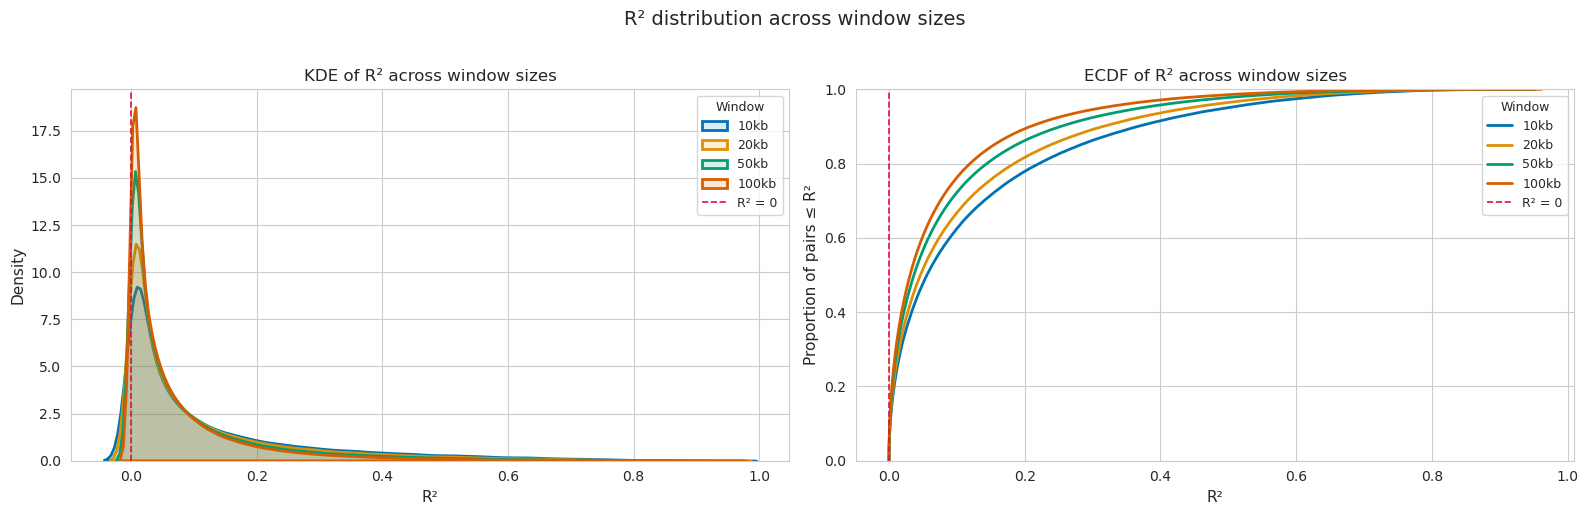

In [21]:
## Plotting R² distribution across windows
#set xlim 
# ── KDE + ECDF combined figure ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
palette = sns.color_palette("colorblind", n_colors=4)

# --- left panel: KDE ----------------------------------------------------------
ax_kde = axes[0]
for color, window_label in zip(palette, window_labels):
    subset = lm_res_df[lm_res_df["window"] == window_label]["r_squared"].dropna()
    sns.kdeplot(subset, ax=ax_kde, label=window_label, color=color,
                linewidth=2.0, fill=True, alpha=0.15)

ax_kde.axvline(0.0, color="crimson", linestyle="--", linewidth=1.2, label="R² = 0")
ax_kde.set_xlabel("R²", fontsize=11)
ax_kde.set_ylabel("Density", fontsize=11)
ax_kde.set_title("KDE of R² across window sizes", fontsize=12)
ax_kde.legend(title="Window", fontsize=9, title_fontsize=9)

# --- right panel: ECDF --------------------------------------------------------
ax_ecdf = axes[1]
for color, window_label in zip(palette, window_labels):
    subset = lm_res_df[lm_res_df["window"] == window_label]["r_squared"].dropna()
    sns.ecdfplot(subset, ax=ax_ecdf, label=window_label, color=color, linewidth=2.0)

ax_ecdf.axvline(0.0, color="crimson", linestyle="--", linewidth=1.2, label="R² = 0")
ax_ecdf.set_xlabel("R²", fontsize=11)
ax_ecdf.set_ylabel("Proportion of pairs ≤ R²", fontsize=11)
ax_ecdf.set_title("ECDF of R² across window sizes", fontsize=12)
ax_ecdf.legend(title="Window", fontsize=9, title_fontsize=9)

fig.suptitle("R² distribution across window sizes", y=1.02, fontsize=14)
plt.tight_layout()

fig.savefig(
    "/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Graphics/"
    "peak_gene_r_squared_kde_ecdf_ct.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

KDE: shows r^2 distribution shape in each window
- r^2 peak near 0 increasing by larger window size means added peaks have almost no explanatory power
- right tail is a subset of peaks that are strong regulators
- shrinking right tail by increasing window size means distal peaks are weaker regulators

ECDF: shows how much fraction of peak-gene pairs falls into any r^2-threshold
- the proportion of R^2 in the lower region (<= 0.2) increases exponentially by larger window sizes, indicating dilution of (distal) peaks with almost no/very low explanatory power; diluted by a growing background of non-regulatory peaks

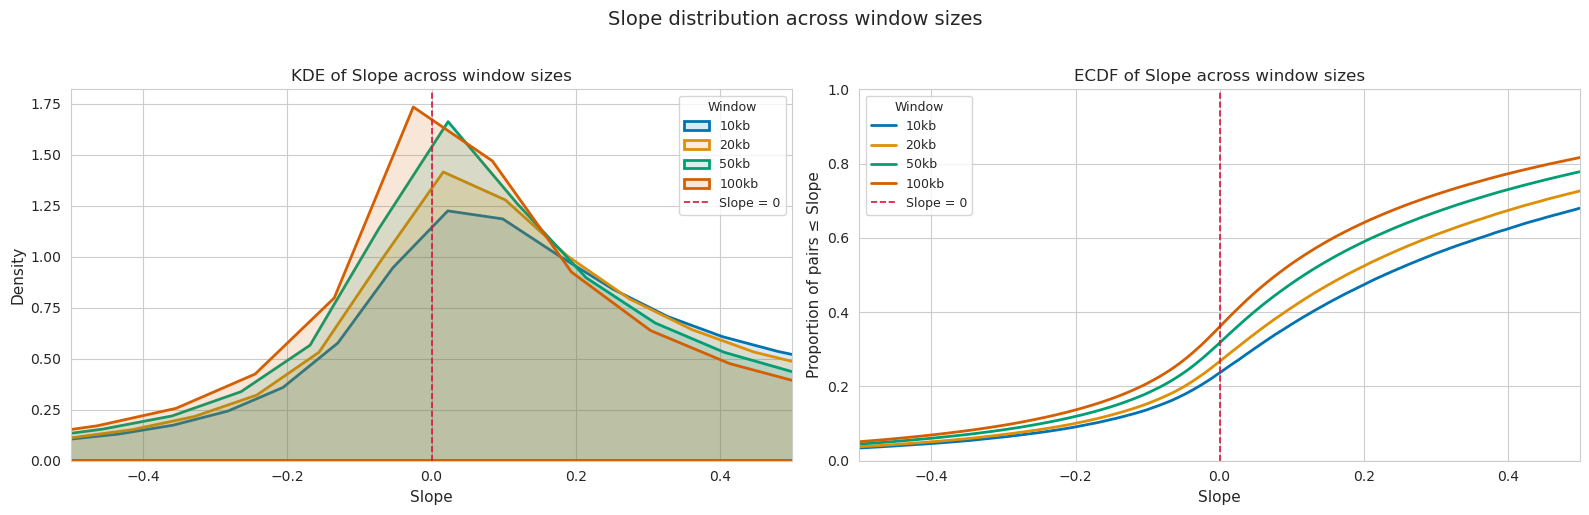

In [22]:
## Plotting slope distribution across windows
#set x-axis symmetric around 0

# ── KDE + ECDF combined figure ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
palette = sns.color_palette("colorblind", n_colors=4)

# --- left panel: KDE ----------------------------------------------------------
ax_kde = axes[0]
for color, window_label in zip(palette, window_labels):
    subset = lm_res_df[lm_res_df["window"] == window_label]["slope"].dropna()
    sns.kdeplot(subset, ax=ax_kde, label=window_label, color=color,
                linewidth=2.0, fill=True, alpha=0.15)

ax_kde.axvline(0.0, color="crimson", linestyle="--", linewidth=1.2, label="Slope = 0")
ax_kde.set_xlim(-0.5, 0.5)  # adjust as needed based on observed slope range
ax_kde.set_xlabel("Slope", fontsize=11)
ax_kde.set_ylabel("Density", fontsize=11)
ax_kde.set_title("KDE of Slope across window sizes", fontsize=12)
ax_kde.legend(title="Window", fontsize=9, title_fontsize=9)

# --- right panel: ECDF --------------------------------------------------------
ax_ecdf = axes[1]
for color, window_label in zip(palette, window_labels):
    subset = lm_res_df[lm_res_df["window"] == window_label]["slope"].dropna()
    sns.ecdfplot(subset, ax=ax_ecdf, label=window_label, color=color, linewidth=2.0)

ax_ecdf.axvline(0.0, color="crimson", linestyle="--", linewidth=1.2, label="Slope = 0")
ax_ecdf.set_xlim(-0.5, 0.5)  # adjust as needed based on observed slope range
ax_ecdf.set_xlabel("Slope", fontsize=11)
ax_ecdf.set_ylabel("Proportion of pairs ≤ Slope", fontsize=11)
ax_ecdf.set_title("ECDF of Slope across window sizes", fontsize=12)
ax_ecdf.legend(title="Window", fontsize=9, title_fontsize=9)

fig.suptitle("Slope distribution across window sizes", y=1.02, fontsize=14)
plt.tight_layout()

fig.savefig(
    "/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Graphics/"
    "peak_gene_slope_kde_ecdf_ct.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

In [ ]:
meaning???

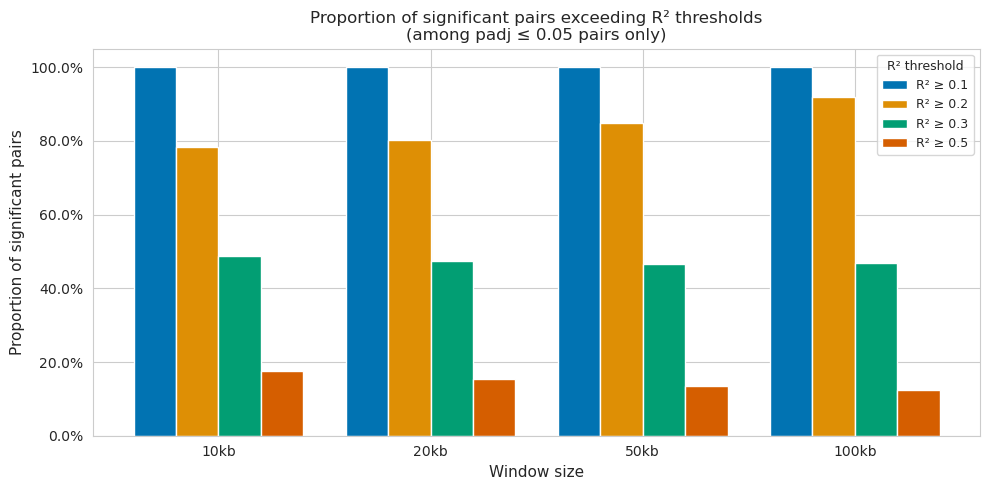

In [23]:
#Plotting proportion of variance explained across windows
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns


window_labels = ["10kb", "20kb", "50kb", "100kb"]

r2_thresholds = [0.1, 0.2, 0.3, 0.5]
records = []

for window_label in window_labels:
    subset = lm_res_df[
        (lm_res_df["window"] == window_label) &
        (lm_res_df["padj"] <= 0.05)           # among significant pairs only
    ]["r_squared"].dropna()
    n = len(subset)
    for t in r2_thresholds:
        records.append({
            "window":     window_label,
            "threshold":  f"R² ≥ {t}",
            "proportion": (subset >= t).sum() / n if n > 0 else np.nan,
            "n_sig":      (subset >= t).sum(),
            "n_total":    n,
        })

r2_prop_df = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(10, 5))
x     = np.arange(len(window_labels))
width = 0.2
palette = sns.color_palette("colorblind", n_colors=len(r2_thresholds))

for j, (threshold_label, color) in enumerate(
    zip(r2_prop_df["threshold"].unique(), palette)
):
    vals = r2_prop_df[r2_prop_df["threshold"] == threshold_label]
    ax.bar(x + j * width, vals["proportion"],
           width=width, label=threshold_label,
           color=color, edgecolor="white")

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(window_labels)
ax.set_xlabel("Window size", fontsize=11)
ax.set_ylabel("Proportion of significant pairs", fontsize=11)
ax.set_title("Proportion of significant pairs exceeding R² thresholds\n"
             "(among padj ≤ 0.05 pairs only)", fontsize=12)
ax.yaxis.set_major_formatter(
    plt.matplotlib.ticker.PercentFormatter(xmax=1, decimals=1)
)
ax.legend(title="R² threshold", fontsize=9, title_fontsize=9)
plt.tight_layout()
fig.savefig(
    "/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Graphics/"
    "peak_gene_r2_proportion_ct.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

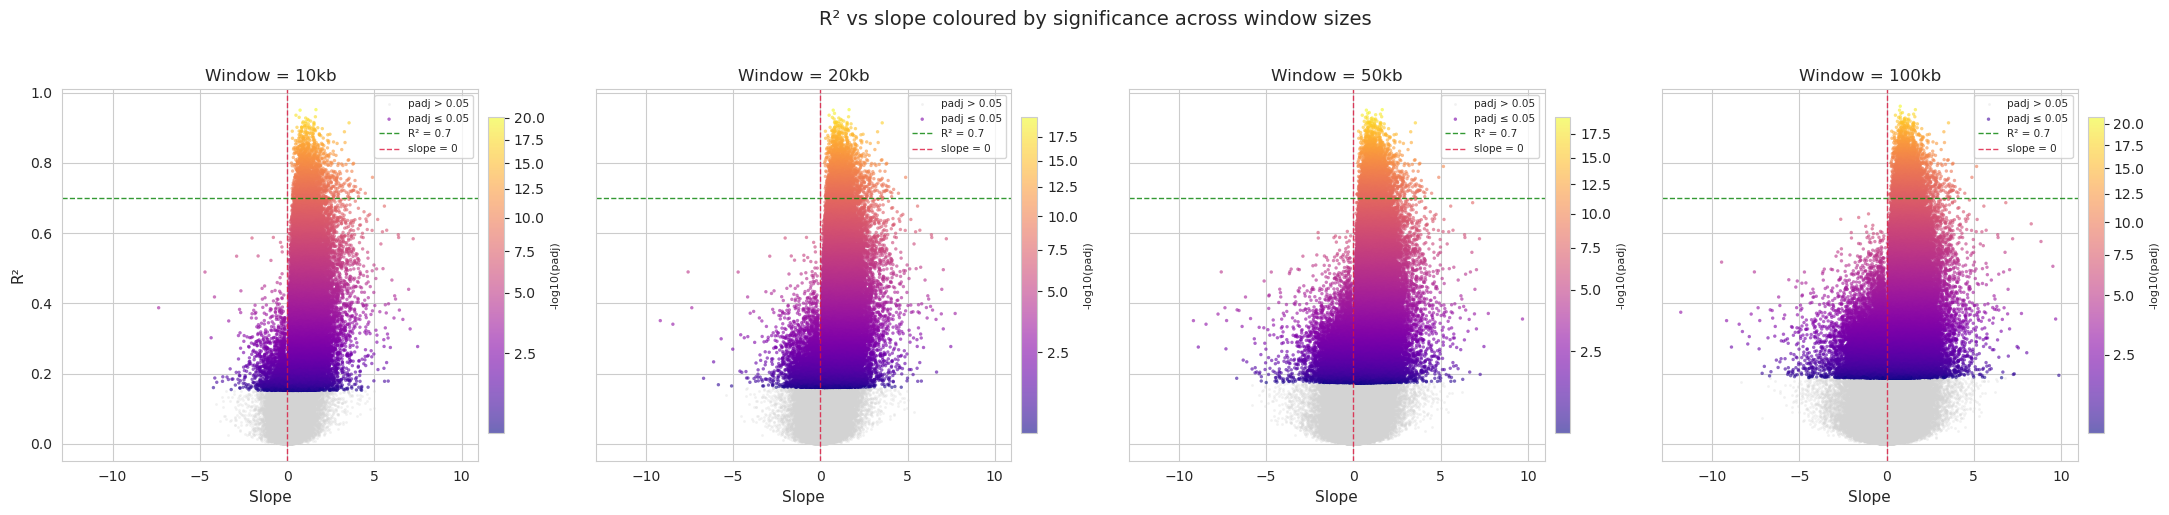

In [24]:
#plotting R^2 vs slope coloured by −log10(padj <= 0.05)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns


window_labels = ["10kb", "20kb", "50kb", "100kb"]

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharex=True, sharey=True)

for i, (ax, window_label) in enumerate(zip(axes, window_labels)):
    subset = lm_res_df[lm_res_df["window"] == window_label].dropna(
        subset=["slope", "r_squared", "padj"]
    )

    # split into significant and non-significant
    sig     = subset[subset["padj"] <= 0.05]
    non_sig = subset[subset["padj"] >  0.05]

    # non-significant in grey
    ax.scatter(
        non_sig["slope"], non_sig["r_squared"],
        c="lightgrey", s=4, alpha=0.3,
        linewidth=0, rasterized=True, label="padj > 0.05"
    )

    # significant coloured by -log10(padj)
    sc = ax.scatter(
        sig["slope"], sig["r_squared"],
        c=sig["neglog10_padj"],
        cmap="plasma", s=6, alpha=0.6,
        linewidth=0, rasterized=True,
        norm=mcolors.PowerNorm(gamma=0.5),  # compress high values
        label="padj ≤ 0.05"
    )
    cb = fig.colorbar(sc, ax=ax, pad=0.02, shrink=0.85)
    cb.set_label("-log10(padj)", fontsize=8)

    ax.axhline(0.7, color="green", linestyle="--",
               linewidth=1.0, alpha=0.8, label="R² = 0.7")
    ax.axvline(0.0, color="crimson", linestyle="--",
               linewidth=1.0, alpha=0.8, label="slope = 0")
    ax.set_xlabel("Slope", fontsize=11)
    ax.set_ylabel("R²" if i == 0 else "", fontsize=11)
    ax.set_title(f"Window = {window_label}", fontsize=12)
    ax.legend(fontsize=7.5, loc="upper right", frameon=True)

fig.suptitle("R² vs slope coloured by significance across window sizes",
             y=1.02, fontsize=14)
plt.tight_layout()
fig.savefig(
    "/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Graphics/"
    "peak_gene_r2_slope_padj_ct.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

High R², high slope, bright colour --> Strong, reliable, significant activating peak — top candidate regulatory element
High R², negative slope, bright colour --> Strong repressive relationship — worth investigating
High R², low slope, bright colour --> Peak explains much expression variance but effect per unit accessibility is small — could reflect a highly sensitive regulatory element operating in a narrow accessibility range
Low R², high slope --> Steep but noisy relationship — few data points drive the slope, unreliable
Cluster of grey points at low R² near slope = 0 --> The expected bulk of non-regulatory background peaks

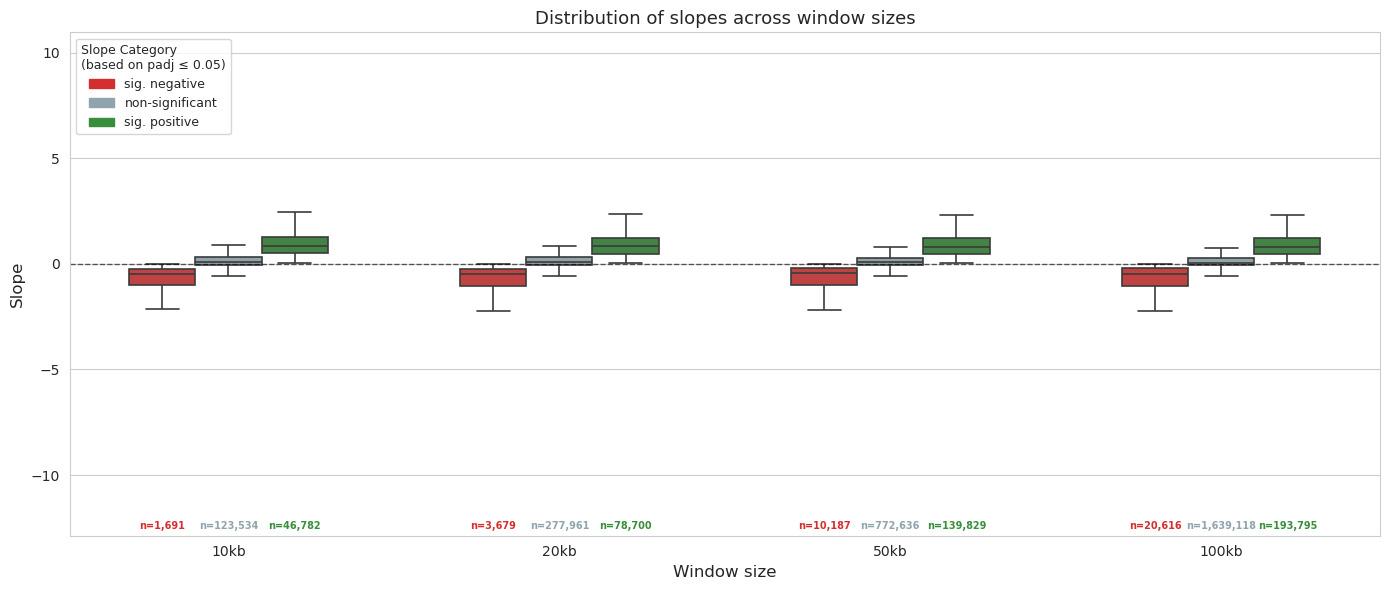

In [33]:
#Distribution of significant pairs (padj ≤ 0.05) per slope category across windows
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── classify every peak–gene pair into one of three categories ────────────────
def classify_pair(row):
    if row["padj"] <= 0.05 and row["slope"] < 0:
        return "sig. negative"
    elif row["padj"] <= 0.05 and row["slope"] > 0:
        return "sig. positive"
    else:
        return "non-significant"

lm_res_df["category"] = lm_res_df.apply(classify_pair, axis=1)

category_order  = ["sig. negative", "non-significant", "sig. positive"]
category_colors = {
    "sig. negative":   "#D32F2F",
    "non-significant": "#90A4AE",
    "sig. positive":   "#388E3C",
}


# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=lm_res_df.dropna(subset=["slope", "padj", "category"]),
    x="window",
    y="slope",
    hue="category",
    hue_order=category_order,
    order=window_labels,
    palette=category_colors,
    width=0.6,
    linewidth=1.2,
    flierprops=dict(
        marker=".",
        markersize=1.5,
        alpha=0.2,
        markeredgewidth=0
    ),
    ax=ax
)

# ── overlay stripplot for individual points (downsampled to avoid overplot)
for cat in category_order:
        cat_data = subset[subset["slope"] == cat]
        # downsample to max 500 points per category for readability
        if len(cat_data) > 1000:
            cat_data = cat_data.sample(1000, random_state=42)
        x_pos = category_order.index(cat)
        ax.scatter(
            np.random.normal(x_pos, 0.08, size=len(cat_data)),
            cat_data["slope"],
            color=category_colors[cat],
            alpha=0.25,
            s=4,
            linewidths=0,
            zorder=2
        )

# ── annotate n per window per category ───────────────────────────────────────
n_groups   = len(category_order)
n_windows  = len(window_labels)
total_width = 0.6                          # matches boxplot width=
box_width   = total_width / n_groups

for w_idx, window_label in enumerate(window_labels):
    subset = lm_res_df[lm_res_df["window"] == window_label].dropna(
        subset=["slope", "padj", "category"]
    )
    for c_idx, cat in enumerate(category_order):
        n = (subset["category"] == cat).sum()

        # compute x position matching seaborn's internal grouping
        median = subset[subset["category"] == cat]["slope"].min()
        x_pos = (
            w_idx
            - total_width / 2
            + box_width / 2
            + c_idx * box_width
        )
        #x_offset = 0.055 * (ax.get_xlim()[1] - ax.get_xlim()[0])
        ax.text(
            x=x_pos,  # + x_offset
            y=ax.get_ylim()[0] + 0.02 * (ax.get_ylim()[1] - ax.get_ylim()[0]),
            s=f"n={n:,}",
            ha="center",
            va="center",
            fontsize=7,
            fontweight="bold",
            color=category_colors[cat],
        )


# ── reference line at r = 0 ───────────────────────────────────────────────────
ax.axhline(0.0, color="black", linestyle="--",
           linewidth=1.0, alpha=0.6, label="r = 0")

ax.set_xlabel("Window size", fontsize=12)
ax.set_ylabel("Slope", fontsize=12)
ax.set_title(
    "Distribution of slopes across window sizes",
    fontsize=13
)

# ── legend ────────────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color=category_colors[cat], label=cat)
    for cat in category_order
]
ax.legend(
    handles=legend_patches,
    title="Slope Category\n(based on padj ≤ 0.05)",
    fontsize=9,
    title_fontsize=9,
    frameon=True,
    loc="upper left",
)

plt.tight_layout()

fig.savefig(
    "/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Graphics/"
    "peak_gene_slope_boxplot_combined_ct2.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

In [34]:
#count the number of significant peaks and non-significant peaks for each gene in all window sizes in lm_res_df
gene_significance_summary = []
for gene_id in lm_res_df["gene"].unique():
    gene_data = lm_res_df[lm_res_df["gene"] == gene_id]
    for window in window_labels:
        window_data = gene_data[gene_data["window"] == window]
        n_sig_pos = ((window_data["padj"] <= 0.05) & (window_data["slope"] > 0)).sum()
        n_sig_neg = ((window_data["padj"] <= 0.05) & (window_data["slope"] < 0)).sum()
        n_non_sig = ((window_data["padj"] > 0.05) | (window_data["padj"].isna())).sum()

        gene_significance_summary.append({
            "gene": gene_id,
            "window": window,
            "n_sig_pos": n_sig_pos,
            "n_sig_neg": n_sig_neg,
            "n_non_sig": n_non_sig,
            "n_total": len(window_data)
        })
gene_significance_summary_df = pd.DataFrame(gene_significance_summary)
print(gene_significance_summary_df.head())

    gene window  n_sig_pos  n_sig_neg  n_non_sig  n_total
0  rpl24   10kb          0          0         13       13
1  rpl24   20kb          0          0         19       19
2  rpl24   50kb          0          0         31       31
3  rpl24  100kb          0          2         55       57
4  cep97   10kb          3          0         10       13


In [53]:
lm_res_df.head()
print(agg_df.head())
print(gene_significance_summary_df.head())

  window  gene         category  count
0   10kb  a1cf  non-significant      7
1   10kb  a1cf    sig. negative      0
2   10kb  a1cf    sig. positive      4
3   10kb  a2ml  non-significant     11
4   10kb  a2ml    sig. negative      0
    gene window  n_sig_pos  n_sig_neg  n_non_sig  n_total
0  rpl24   10kb          0          0         13       13
1  rpl24   20kb          0          0         19       19
2  rpl24   50kb          0          0         31       31
3  rpl24  100kb          0          2         55       57
4  cep97   10kb          3          0         10       13


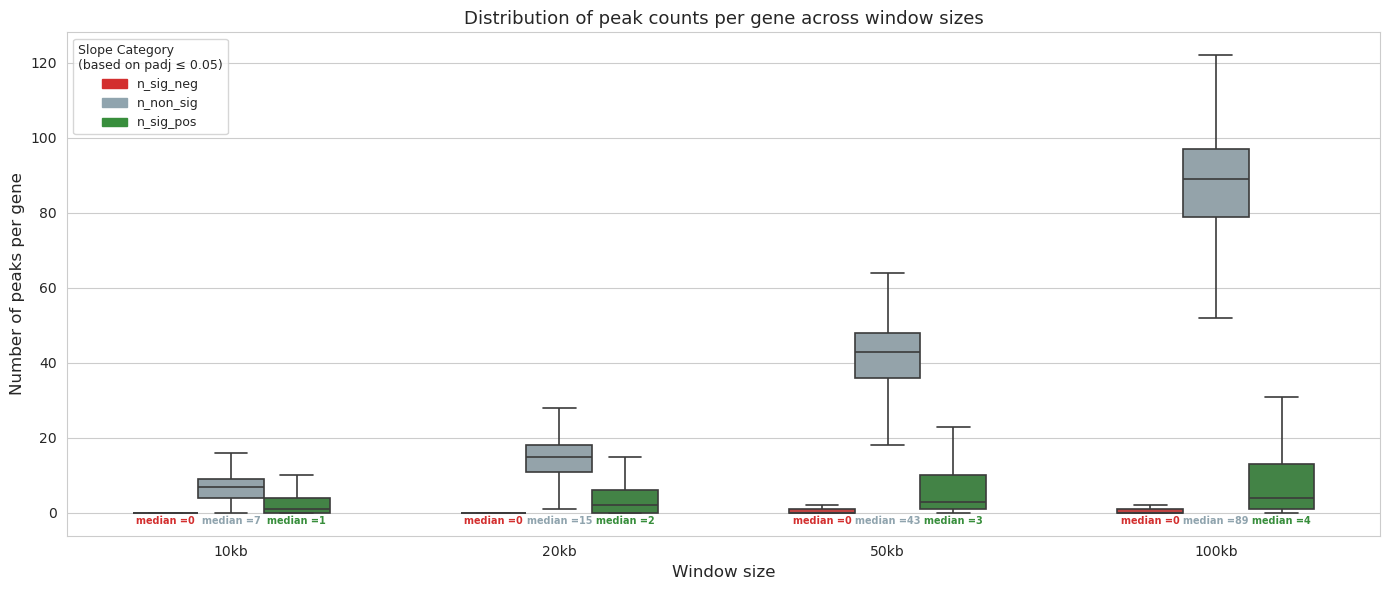

In [57]:
# Plotting the distribution of the number of peaks per gene across all window sizes
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd

# ensure plot order is stable
window_labels = ["10kb", "20kb", "50kb", "100kb"]
category_order = ["n_sig_neg", "n_non_sig", "n_sig_pos"]
category_colors = {
    "n_sig_neg": "#D32F2F",
    "n_non_sig": "#90A4AE",
    "n_sig_pos": "#388E3C",
}

# reshape to long format: one row per (gene, window, category)
plot_df = gene_significance_summary_df.melt(
    id_vars=["gene", "window"],
    value_vars=category_order,
    var_name="category",
    value_name="count",
)

plot_df["window"] = pd.Categorical(
    plot_df["window"],
    categories=window_labels,
    ordered=True,
)

# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=plot_df.dropna(subset=["count"]),
    x="window",
    y="count",
    hue="category",
    hue_order=category_order,
    order=window_labels,
    palette=category_colors,
    width=0.6,
    linewidth=1.2,
    flierprops=dict(
        marker=".",
        markersize=1.5,
        alpha=0.2,
        markeredgewidth=0,
    ),
    ax=ax,
)

# annotate median count for each window-category box
n_groups = len(category_order)
total_width = 0.6
box_width = total_width / n_groups

for w_idx, window_label in enumerate(window_labels):
    w_subset = plot_df[plot_df["window"] == window_label]
    for c_idx, cat in enumerate(category_order):
        vals = w_subset[w_subset["category"] == cat]["count"]
        if vals.empty:
            continue

        x_pos = (
            w_idx
            - total_width / 2
            + box_width / 2
            + c_idx * box_width
        )
        y_med = vals.median()
        ax.text(
            x=x_pos,
            y = ax.get_ylim()[0] + 0.02 * (ax.get_ylim()[1] - ax.get_ylim()[0]), # place text slightly above x-axis
            s=f"median ={int(y_med):,}",
            ha="center",
            va="bottom",
            fontsize=7,
            fontweight="bold",
            color=category_colors[cat],
        )

# ── labels + legend ───────────────────────────────────────────────────────────
ax.set_xlabel("Window size", fontsize=12)
ax.set_ylabel("Number of peaks per gene", fontsize=12)
ax.set_title("Distribution of peak counts per gene across window sizes", fontsize=13)

legend_patches = [
    mpatches.Patch(color=category_colors[cat], label=cat)
    for cat in category_order
]
ax.legend(
    handles=legend_patches,
    title="Slope Category\n(based on padj ≤ 0.05)",
    fontsize=9,
    title_fontsize=9,
    frameon=True,
    loc="upper left",
)

plt.tight_layout()
plt.show()

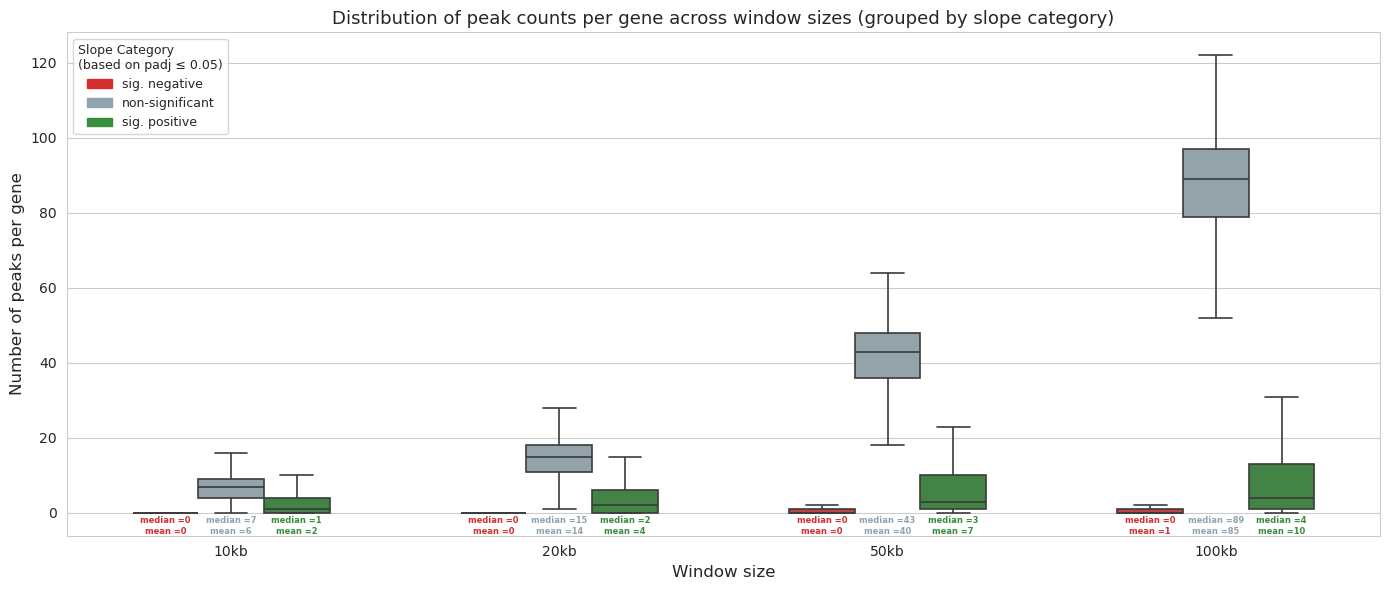

In [64]:
# Plotting the distribution of peak counts per gene across all window sizes (aggregated by category)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd

# ensure plot order is stable
window_labels = ["10kb", "20kb", "50kb", "100kb"]
category_order = ["sig. negative", "non-significant", "sig. positive"]
category_colors = {
    "sig. negative": "#D32F2F",
    "non-significant": "#90A4AE",
    "sig. positive": "#388E3C",
}

# agg_df is already in long format: (window, gene, category, count)
# ensure window is categorical for proper ordering
plot_df = agg_df.copy()
plot_df["window"] = pd.Categorical(
    plot_df["window"],
    categories=window_labels,
    ordered=True,
)

# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=plot_df.dropna(subset=["count"]),
    x="window",
    y="count",
    hue="category",
    hue_order=category_order,
    order=window_labels,
    palette=category_colors,
    width=0.6,
    linewidth=1.2,
    flierprops=dict(
        marker=".",
        markersize=1.5,
        alpha=0.2,
        markeredgewidth=0,
    ),
    ax=ax,
)

# annotate median count for each window-category box
n_groups = len(category_order)
total_width = 0.6
box_width = total_width / n_groups

for w_idx, window_label in enumerate(window_labels):
    w_subset = plot_df[plot_df["window"] == window_label]
    for c_idx, cat in enumerate(category_order):
        vals = w_subset[w_subset["category"] == cat]["count"]
        if vals.empty:
            continue

        x_pos = (
            w_idx
            - total_width / 2
            + box_width / 2
            + c_idx * box_width
        )
        y_med = vals.median()
        y_mean = vals.mean()
        ax.text(
            x=x_pos,
            y=ax.get_ylim()[0] + 0.00001  * (ax.get_ylim()[1] - ax.get_ylim()[0]), # place text slightly above x-axis
            s=f"median ={int(y_med):,}\nmean ={int(y_mean):,}",
            ha="center",
            va="bottom",
            fontsize=6,
            fontweight="bold",
            color=category_colors[cat],
        )

# ── labels + legend ───────────────────────────────────────────────────────────
ax.set_xlabel("Window size", fontsize=12)
ax.set_ylabel("Number of peaks per gene", fontsize=12)
ax.set_title("Distribution of peak counts per gene across window sizes (grouped by slope category)", fontsize=13)

legend_patches = [
    mpatches.Patch(color=category_colors[cat], label=cat)
    for cat in category_order
]
ax.legend(
    handles=legend_patches,
    title="Slope Category\n(based on padj ≤ 0.05)",
    fontsize=9,
    title_fontsize=9,
    frameon=True,
    loc="upper left",
)

plt.tight_layout()

fig.savefig(
    "/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Graphics/"
    "peak_gene_count_boxplot_aggregated_ct.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

In [ ]:
#Distribution of significant pairs (padj ≤ 0.05) per slope category across windows
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── classify every peak–gene pair into one of three categories ────────────────
def classify_pair(row):
    if row["padj"] <= 0.05 and row["slope"] < 0:
        return "sig. negative"
    elif row["padj"] <= 0.05 and row["slope"] > 0:
        return "sig. positive"
    else:
        return "non-significant"

lm_res_df["category"] = lm_res_df.apply(classify_pair, axis=1)

category_order  = ["sig. negative", "non-significant", "sig. positive"]
category_colors = {
    "sig. negative":   "#D32F2F",
    "non-significant": "#90A4AE",
    "sig. positive":   "#388E3C",
}


# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=lm_res_df.dropna(subset=["slope", "padj", "category"]),
    x="window",
    y="slope",
    hue="category",
    hue_order=category_order,
    order=window_labels,
    palette=category_colors,
    width=0.6,
    linewidth=1.2,
    flierprops=dict(
        marker=".",
        markersize=1.5,
        alpha=0.2,
        markeredgewidth=0
    ),
    ax=ax
)

# ── overlay stripplot for individual points (downsampled to avoid overplot)
for cat in category_order:
        cat_data = subset[subset["slope"] == cat]
        # downsample to max 500 points per category for readability
        if len(cat_data) > 1000:
            cat_data = cat_data.sample(1000, random_state=42)
        x_pos = category_order.index(cat)
        ax.scatter(
            np.random.normal(x_pos, 0.08, size=len(cat_data)),
            cat_data["slope"],
            color=category_colors[cat],
            alpha=0.25,
            s=4,
            linewidths=0,
            zorder=2
        )

# ── annotate n per window per category ───────────────────────────────────────
n_groups   = len(category_order)
n_windows  = len(window_labels)
total_width = 0.6                          # matches boxplot width=
box_width   = total_width / n_groups

for w_idx, window_label in enumerate(window_labels):
    subset = lm_res_df[lm_res_df["window"] == window_label].dropna(
        subset=["slope", "padj", "category"]
    )
    for c_idx, cat in enumerate(category_order):
        n = (subset["category"] == cat).sum()

        # compute x position matching seaborn's internal grouping
        median = subset[subset["category"] == cat]["slope"].min()
        x_pos = (
            w_idx
            - total_width / 2
            + box_width / 2
            + c_idx * box_width
        )
        #x_offset = 0.055 * (ax.get_xlim()[1] - ax.get_xlim()[0])
        ax.text(
            x=x_pos,  # + x_offset
            y=ax.get_ylim()[0] + 0.02 * (ax.get_ylim()[1] - ax.get_ylim()[0]),
            s=f"n={n:,}",
            ha="center",
            va="center",
            fontsize=7,
            fontweight="bold",
            color=category_colors[cat],
        )


# ── reference line at r = 0 ───────────────────────────────────────────────────
ax.axhline(0.0, color="black", linestyle="--",
           linewidth=1.0, alpha=0.6, label="r = 0")

ax.set_xlabel("Window size", fontsize=12)
ax.set_ylabel("Slope", fontsize=12)
ax.set_title(
    "Distribution of slopes across window sizes",
    fontsize=13
)

# ── legend ────────────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color=category_colors[cat], label=cat)
    for cat in category_order
]
ax.legend(
    handles=legend_patches,
    title="Slope Category\n(based on padj ≤ 0.05)",
    fontsize=9,
    title_fontsize=9,
    frameon=True,
    loc="upper left",
)

plt.tight_layout()

fig.savefig(
    "/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Graphics/"
    "peak_gene_slope_boxplot_combined_ct2.png",
    dpi=300, bbox_inches="tight"
)
plt.show()